# Lecture 2 — Julia and VFI
## 第二讲 —— Julia 与价值函数迭代

**Computational Methods for Heterogeneous-Agent Macro**  
**异质性主体宏观的计算方法**  
Jeffrey Sun

Solve the consumption-savings problem with no income shocks by Value Function Iteration (VFI).

用价值函数迭代（VFI）求解无收入冲击的消费–储蓄问题。

Steps:
1. Define $V$ as a vector on a finite wealth grid.
2. Define the Bellman operator taking $V \mapsto \mathcal{T}V$ as a function taking a vector to a vector.
3. Repeatedly apply $\mathcal{T}\mathcal{T}\cdots\mathcal{T}\mathcal{T}V$ until convergence.

步骤：
1. 把 $V$ 定义为有限财富网格上的一个向量。
2. 把贝尔曼算子 $V \mapsto \mathcal{T}V$ 写成一个把向量映射到向量的函数。
3. 反复作用 $\mathcal{T}\mathcal{T}\cdots\mathcal{T}\mathcal{T}V$，直到收敛。

Notes:
- This code is not very optimized. I am using allocating functions, plain grid search, no Howard improvement, etc., etc.. I wrote it to be clear rather than fast.

说明：
- 这段代码并不追求性能：用的是会分配内存的函数、朴素的网格搜索、没有 Howard 改进等等。写法以清晰为先，不求快。


### Environment
### 运行环境


In [1]:
using Pkg
Pkg.activate("..")
Pkg.instantiate()
using Plots

  Activating project at `~/projects/research/CV is all you need`


# Core Code
# 核心代码


### Utility and Log Grid
### 效用函数与对数网格

CRRA utility on `c > 0`, with the `γ = 1` case routed to `log`. A
log-spaced grid clusters points near the borrowing constraint.

`c > 0` 上的 CRRA 效用，`γ = 1` 时退化为 `log`。对数等距网格把更多点集中在借贷约束附近。


In [10]:
u(c) = c <= 0 ? -Inf : log(c)
loggrid(lo, hi, N) = exp.(range(log(lo), log(hi); length = N))

loggrid (generic function with 1 method)

### Bellman Operator
### 贝尔曼算子

Given a value function (guess) $V$, for each $b$ compute,
$$
TV(b) = \max_{b'} u(c) + \beta V(b')
$$
where
$$
\begin{align*}
    c &= b - b^\text{end}\\
    b^\text{end} &= \frac{b' - y}{R}
\end{align*}
$$

给定一个价值函数（猜测） $V$，对每个 $b$ 计算
$$
TV(b) = \max_{b'} u(c) + \beta V(b'),
$$
其中
$$
\begin{align*}
    c &= b - b^\text{end},\\
    b^\text{end} &= \frac{b' - y}{R}.
\end{align*}
$$


In [28]:
"""
Apply Bellman operator V |-> TV, when V is a vector over the wealth grid and there are no income shocks.

作用一次贝尔曼算子 V |-> TV；V 是定义在财富网格上的向量，且无收入冲击。
"""
function bellman_operator(V, params)
    # Unpack parameters from `params`
    # 从 `params` 解包参数
    (; β, R, w, b_grid) = params

    # Compute saving levels `b_end` necessary to achieve each level of next-period wealth `b_next`
    # 计算到达各个下期财富 `b_next` 所需的期末储蓄水平 `b_end`
    b_end = (b_grid' .- w)./R

    return maximum(u.(b_grid .- b_end) .+ β.*V'; dims=2)
end

bellman_operator

### Value Function Iteration
### 价值函数迭代

Iterate $V \mapsto \mathcal{T}V$ until the max-abs change is below `tol`.

反复迭代 $V \mapsto \mathcal{T}V$，直到最大绝对变化小于 `tol`。


In [4]:
function solve_vfi(params; tol = 1e-6, maxiter = 2000, verbosity=0)
    # Make initial guess of V
    # 给出 V 的初始猜测
    V = zeros(size(params.b_grid))

    Δ = Inf
    iters = 0
    while Δ >= tol
        # Update V
        # 更新 V
        TV = bellman_operator(V, params)

        # Calculate error
        # 计算误差
        Δ = maximum(abs.(TV .- V))

        # Update V
        # 更新 V
        V = TV
        iters = iters + 1

        # If iters > maxiter, then error.
        # 若 iters > maxiter 则抛出错误。
        iters > maxiter && error("VFI did not converge in $maxiter iterations")
    end

    # If verbosity >= 1, then print convergence message.
    # 若 verbosity >= 1，则打印收敛信息。
    verbosity >= 1 && println("VFI converged in $iters iterations with error $Δ")

    return V
end

solve_vfi (generic function with 1 method)

In [5]:
b_grid = loggrid(0.05, 40.0, 400)
params = (;β=0.96, R=1.04, w=1.0, b_grid)

@show solve_vfi(params, verbosity=1)
;

VFI converged in 309 iterations with error 9.86656182533352e-7
solve_vfi(params, verbosity = 1) = [-0.9305646679894642; -0.9296882896554449; -0.928797892228851; -0.9278930864277999; -0.9269732405526309; -0.9260384352898857; -0.9250882111498807; -0.9241222611889457; -0.9231402380183248; -0.922142191807986; -0.9211274067591957; -0.9200958387071952; -0.9190471720617186; -0.9179810400040217; -0.9168974526321667; -0.9157957009319989; -0.9146754948510785; -0.9135367219156282; -0.9123790486397781; -0.9112020816459995; -0.9100057887259506; -0.9087894466421348; -0.9075527336682451; -0.9062954978506561; -0.9050173743503668; -0.9037179401075321; -0.9023969296704596; -0.9010540361195709; -0.8996886489565405; -0.8983004057825731; -0.8968891063197538; -0.895454345046215; -0.8939956596608151; -0.892512738265528; -0.8910052282388237; -0.889472484595438; -0.8879140995835378; -0.8863298201310543; -0.8847191951610975; -0.883081718103521; -0.8814170257753011; -0.8797247148840838; -0.8780041004384753; -0.8

## Solve and plot
## 求解并绘图

V is increasing and concave.
$V$ 单调递增且凹。

With more iterations, the effect of the update gets smaller and smaller.
随着迭代次数增加，每一步更新的幅度越来越小。


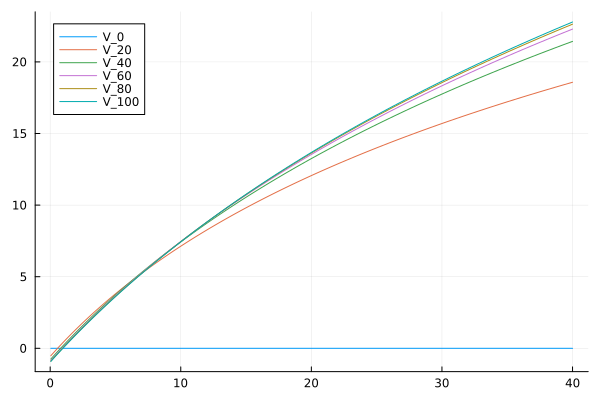

In [43]:
b_grid = loggrid(0.05, 40.0, 400)
params = (;β=0.96, R=1.04, w=1.0, b_grid)

# Guess initial V
# 给出 V 的初始猜测
V = zeros(size(b_grid))
V_0 = copy(V)

for i = 1:20
    V = bellman_operator(V, params)
end
V_20 = copy(V)

for i = 1:20
    V = bellman_operator(V, params)
end
V_40 = copy(V)

for i = 1:20
    V = bellman_operator(V, params)
end
V_60 = copy(V)

for i = 1:20
    V = bellman_operator(V, params)
end
V_80 = copy(V)

for i = 1:20
    V = bellman_operator(V, params)
end
V_100 = copy(V)

plot(b_grid, hcat(V_0, V_20, V_40, V_60, V_80, V_100), label=["V_0" "V_20" "V_40" "V_60" "V_80" "V_100"])

### Policy Function
### 策略函数

The policy function is the same operator as the Bellman operator, with
`argmax` in place of `max`:
$$
c^\star(b) \;=\; \arg\max_{c \in [0, b]} \; u(c) + \beta\, V\!\big(R(b - c) + w\big).
$$

策略函数与贝尔曼算子是同一个算子，只是把 `max` 换成 `argmax`：
$$
c^\star(b) \;=\; \arg\max_{c \in [0, b]} \; u(c) + \beta\, V\!\big(R(b - c) + w\big).
$$


In [ ]:
"""
Compute the policy index vector `c_ind` from V. For each row of b_grid,
returns the column index in b_grid of the optimal next-period wealth b'.
Same operator as `bellman_operator`, with `argmax` instead of `max`.

由 V 算出策略下标向量 `c_ind`。对每个 b（行），返回最优下期财富 b' 在
b_grid 上的下标。与 `bellman_operator` 同一个算子，把 `max` 换成 `argmax`。
"""
function policy_function(V, params)
    (; β, R, w, b_grid) = params

    # same setup as bellman_operator
    # 与 bellman_operator 完全相同的准备
    b_end = (b_grid' .- w) ./ R

    # argmax over b' (columns) — pull out the column index for each row
    # 沿 b'（列）取 argmax；为每一行取出列下标
    idx = argmax(u.(b_grid .- b_end) .+ β .* V'; dims = 2)
    return vec(getindex.(idx, 2))::Vector{Int}
end


In [ ]:
# read the policy off the converged V — c_ind[i] is the chosen b'-index at b_grid[i]
# 从收敛的 V 读出策略——c_ind[i] 是在 b_grid[i] 上所选的 b' 下标
c_ind = policy_function(V, params);


# Step-by-Step Explanation
# 分步讲解


### Utility and Log Grid
### 效用函数与对数网格


In [6]:
u(c) = c <= 0 ? -Inf : log(c)
loggrid(lo, hi, N) = exp.(range(log(lo), log(hi); length = N))

loggrid (generic function with 1 method)

In [47]:
# Compute utility for a certain consumption level,
# 计算某一消费水平的效用，
@show u(2.5)
@show u(3.0)
# for multiple possible consumption levels,
# 计算多个消费水平的效用，
@show u.([1, 2, 3])
# for a whole grid of possible consumption levels.
# 计算整个消费网格上的效用。
@show c_grid = loggrid(0.1, 10.0, 100)
@show u.(c_grid)
;

u(2.5) = 0.9162907318741551
u(3.0) = 1.0986122886681098
u.([1, 2, 3]) = [0.0, 0.6931471805599453, 1.0986122886681098]
c_grid = loggrid(0.1, 10.0, 100) = [0.10000000000000002, 0.10476157527896648, 0.10974987654930565, 0.1149756995397736, 0.12045035402587827, 0.12618568830660207, 0.13219411484660293, 0.13848863713938733, 0.145082877849594, 0.15199110829529341, 0.1592282793341093, 0.1668100537200059, 0.1747528400007684, 0.18307382802953687, 0.1917910261672489, 0.2009233002565048, 0.21049041445120206, 0.22051307399030462, 0.23101297000831603, 0.24201282647943828, 0.2535364493970112, 0.26560877829466867, 0.27825594022071254, 0.29150530628251775, 0.30538555088334157, 0.3199267137797384, 0.3351602650938843, 0.3511191734215132, 0.3678379771828634, 0.38535285937105307, 0.4037017258596556, 0.42292428743895, 0.44306214575838815, 0.46415888336127803, 0.48626015800653544, 0.5094138014816381, 0.5336699231206311, 0.5590810182512225, 0.5857020818056667, 0.6135907273413175, 0.6428073117284323, 0.673415

### Bellman Operator
### 贝尔曼算子


In [25]:
"""
Apply Bellman operator V |-> TV, when V is a vector over the wealth grid and there are no income shocks.

作用一次贝尔曼算子 V |-> TV；V 是定义在财富网格上的向量，且无收入冲击。
"""
function bellman_operator(V, params)
    # Unpack parameters from `params`
    # 从 `params` 解包参数
    (; β, R, w, b_grid) = params

    # Compute saving levels `b_end` necessary to achieve each level of next-period wealth `b_next`
    # 计算到达各个下期财富 `b_next` 所需的期末储蓄水平 `b_end`
    b_end = (b_grid' .- w)./R

    return maximum(u.(b_grid .- b_end) .+ β.*V'; dims=2)
end

bellman_operator

In [14]:
b_grid = loggrid(0.05, 40.0, 400)
β=0.96
R=1.04
w=1.0

# Think of axis 2 (columns) as representing next-period wealth `b_next`.
# 把第 2 维（列）想成下期财富 `b_next`。
# We can get the grid of `b_next` values by simply transposing b_grid.
# 只要把 b_grid 转置一下，就得到 `b_next` 的网格。

# Note that b_grid is a COLUMN vector
# 注意 b_grid 是一个"列"向量
b_grid

400-element Vector{Float64}:
  0.05000000000000001
  0.05084472691408625
  0.05170372509936013
  0.05257723566235905
  0.05346550378300405
  0.05436877878341772
  0.0552873141979048
  0.05622136784411506
  0.0571712018954084
  0.0581370829544426
  ⋮
 34.98264744650447
 35.57366312298553
 36.17466373643799
 36.785817977761766
 37.40729738781163
 38.039276405545884
 38.68193241698849
 39.3354458050184
 40.0

In [15]:
# But b_grid' is a ROW vector
# 而 b_grid' 是一个"行"向量
b_grid'

1×400 adjoint(::Vector{Float64}) with eltype Float64:
 0.05  0.0508447  0.0517037  0.0525772  …  38.0393  38.6819  39.3354  40.0

In [52]:
w = 0.5

# Then, the end-of-period wealth necessary to achieve each `b_next` is given by,
# 那么，达到每个 `b_next` 所需的期末财富由下式给出：
@show b_end = (b_grid' .- w)./R
# Note that `b_end` is still a row vector, because every entry in b_end corresponds to a different level of b_next.
# 注意 `b_end` 仍是行向量，因为 b_end 的每个元素对应一个不同的 b_next。

# Another way to think about it:
# 另一种理解方式：
# b_next_grid = b_grid'
# b_end = (b_next_grid .- w)./R

# For each current level of wealth (row), a household must choose their next-period wealth `b_next` (column).
# 对每个当期财富水平（行），家庭必须选择其下期财富 `b_next`（列）。
# The possible utilities are then going to be MATRIX, with a ROW for each possible b, and a COLUMN for each possible b_next.
# 于是可能的效用构成一个"矩阵"：每个可能的 b 对应一行，每个可能的 b_next 对应一列。
u.(b_grid .- b_end)

b_end = (b_grid' .- w) ./ R = [-0.4326923076923077 -0.43188007027491704 -0.4310541104813845 -0.4302141964785009 -0.4293600925163422 -0.42849155886209833 -0.42760835173278383 -0.4267102232268124 -0.425796921254415 -0.4248681894668821 -0.4239237671846113 -0.4229633893239385 -0.42198678632273373 -0.420993684064739 -0.41998380380262895 -0.41895686207977073 -0.4179125706506625 -0.416850636400028 -0.41577076126054346 -0.41467264212917543 -0.41355597078210454 -0.4124204337882125 -0.4112657124211069 -0.41009148256965994 -0.4088974146470362 -0.40768317349818267 -0.40644841830575656 -0.40519280249446354 -0.40391597363377946 -0.40261757333902926 -0.40129723717079446 -0.39995459453262067 -0.3985892685669976 -0.39720087604958126 -0.3957890272816294 -0.39435332598061934 -0.39289336916901824 -0.39140874706117396 -0.3898990429482947 -0.38836383308148636 -0.38680268655281275 -0.38521516517434706 -0.38360082335517987 -0.3819592079763489 -0.3802898582636565 -0.37859230565833735 -0.3768660736855424 -0.375

400×400 Matrix{Float64}:
 -0.728376  -0.73006   -0.731776  …  -Inf        -Inf        -Inf
 -0.726627  -0.728309  -0.730021     -Inf        -Inf        -Inf
 -0.724852  -0.726531  -0.72824      -Inf        -Inf        -Inf
 -0.723051  -0.724726  -0.726432     -Inf        -Inf        -Inf
 -0.721222  -0.722894  -0.724597     -Inf        -Inf        -Inf
 -0.719366  -0.721035  -0.722735  …  -Inf        -Inf        -Inf
 -0.717482  -0.719148  -0.720844     -Inf        -Inf        -Inf
 -0.715569  -0.717232  -0.718926     -Inf        -Inf        -Inf
 -0.713628  -0.715288  -0.716978     -Inf        -Inf        -Inf
 -0.711659  -0.713315  -0.715002     -Inf        -Inf        -Inf
  ⋮                               ⋱                          
  3.56715    3.56712    3.5671       -Inf        -Inf        -Inf
  3.5837     3.58367    3.58365      -Inf        -Inf        -Inf
  3.60025    3.60023    3.6002       -Inf        -Inf        -Inf
  3.61681    3.61678    3.61676       -2.62525   -Inf  

In [51]:
# Now let's solve the decision problem.
# 现在来求解决策问题。
# Suppose we have some guess for V
# 假设我们有一个对 V 的猜测
V = ones(size(b_grid))

# We can define `V_next` to be the (guessed) value of having each next-period wealth `b_next`.
# 可以把 `V_next` 定义为持有各个下期财富 `b_next` 的（猜测）价值。
# The grid of `V_next` values for each b_next is simply V'.
# 各个 b_next 对应的 `V_next` 值网格就是 V'。
# Then, the matrix of u + βV_next is,
# 于是 u + βV_next 矩阵为：
u.(b_grid .- b_end) .+ β.*V'

400×400 Matrix{Float64}:
 0.231624  0.22994   0.228224  0.226477  …  -Inf        -Inf       -Inf
 0.233373  0.231691  0.229979  0.228234     -Inf        -Inf       -Inf
 0.235148  0.233469  0.23176   0.230019     -Inf        -Inf       -Inf
 0.236949  0.235274  0.233568  0.231829     -Inf        -Inf       -Inf
 0.238778  0.237106  0.235403  0.233668     -Inf        -Inf       -Inf
 0.240634  0.238965  0.237265  0.235533  …  -Inf        -Inf       -Inf
 0.242518  0.240852  0.239156  0.237427     -Inf        -Inf       -Inf
 0.244431  0.242768  0.241074  0.239349     -Inf        -Inf       -Inf
 0.246372  0.244712  0.243022  0.2413       -Inf        -Inf       -Inf
 0.248341  0.246685  0.244998  0.24328      -Inf        -Inf       -Inf
 ⋮                                       ⋱                         
 4.52715   4.52712   4.5271    4.52708      -Inf        -Inf       -Inf
 4.5437    4.54367   4.54365   4.54363      -Inf        -Inf       -Inf
 4.56025   4.56023   4.5602    4.56018     

In [18]:
# The solution to the household's decision problem is simply,
# 家庭决策问题的解就是：
maximum(u.(b_grid .- b_end) .+ β.*V'; dims=2)

400×1 Matrix{Float64}:
 0.9227772895093918
 0.9236536678434111
 0.924544065270005
 0.9254486932694534
 0.9263677661011087
 0.9273015008266657
 0.9282501173331759
 0.9292138383557837
 0.9301928895001667
 0.9311874992646566
 ⋮
 4.540628904800286
 4.556959449356432
 4.573296844926106
 4.589640983295839
 4.605991757871919
 4.622349063659033
 4.638712797239094
 4.655082856750253
 4.671459141866102

In [31]:
# What happens if we apply the Bellman operator over and over?
# 反复作用贝尔曼算子会怎样？
# Set up params
# 设置参数
b_grid = loggrid(0.05, 40.0, 400)
params = (;β=0.96, R=1.04, w=1.0, b_grid)

# Guess V
# 给出 V 的猜测
V = zeros(size(b_grid))
res_mat = hcat(b_grid, V)

for i = 1:200
    V = bellman_operator(V, params)
    res_mat = hcat(res_mat, V)
end

res_mat

400×102 Matrix{Float64}:
  0.05       0.0  -0.0372227  -0.0729565  …  -0.913533  -0.914215  -0.914869
  0.0508447  0.0  -0.0363463  -0.0720801     -0.912657  -0.913338  -0.913992
  0.0517037  0.0  -0.0354559  -0.0711897     -0.911767  -0.912448  -0.913102
  0.0525772  0.0  -0.0345513  -0.0702849     -0.910862  -0.911543  -0.912197
  0.0534655  0.0  -0.0336322  -0.0693651     -0.909942  -0.910623  -0.911277
  0.0543688  0.0  -0.0326985  -0.0684303  …  -0.909007  -0.909688  -0.910343
  0.0552873  0.0  -0.0317499  -0.0674801     -0.908057  -0.908738  -0.909392
  0.0562214  0.0  -0.0307862  -0.0665143     -0.907091  -0.907772  -0.908426
  0.0571712  0.0  -0.0298071  -0.0655327     -0.906109  -0.90679   -0.907444
  0.0581371  0.0  -0.0288125  -0.064535      -0.905111  -0.905792  -0.906446
  ⋮                                       ⋱              ⋮         
 34.9826     0.0   3.58063     5.74746       20.7914    20.7957    20.7998
 35.5737     0.0   3.59696     5.77867       21.0338    21.038

In [33]:
# The initial guess doesn't change the limit that V converges to.
# 初始猜测不会改变 V 的收敛极限。
# Guess V
# 给出 V 的猜测
V = ones(size(b_grid))
res_mat = hcat(b_grid, V)

for i = 1:200
    V = bellman_operator(V, params)
    res_mat = hcat(res_mat, V)
end

res_mat

400×202 Matrix{Float64}:
  0.05       1.0  0.922777  0.848643  …  -0.929972  -0.929995  -0.930018
  0.0508447  1.0  0.923654  0.84952      -0.929095  -0.929119  -0.929142
  0.0517037  1.0  0.924544  0.85041      -0.928205  -0.928229  -0.928252
  0.0525772  1.0  0.925449  0.851315     -0.9273    -0.927324  -0.927347
  0.0534655  1.0  0.926368  0.852235     -0.92638   -0.926404  -0.926427
  0.0543688  1.0  0.927302  0.85317   …  -0.925445  -0.925469  -0.925492
  0.0552873  1.0  0.92825   0.85412      -0.924495  -0.924519  -0.924542
  0.0562214  1.0  0.929214  0.855086     -0.923529  -0.923553  -0.923576
  0.0571712  1.0  0.930193  0.856067     -0.922547  -0.922571  -0.922594
  0.0581371  1.0  0.931187  0.857065     -0.921549  -0.921573  -0.921596
  ⋮                                   ⋱              ⋮         
 34.9826     1.0  4.54063   6.66906      20.8975    20.8975    20.8976
 35.5737     1.0  4.55696   6.70027      21.1425    21.1426    21.1427
 36.1747     1.0  4.5733    6.7315     

### Value Function Iteration (VFI)
### 价值函数迭代（VFI）


In [ ]:
function solve_vfi(params; tol = 1e-6, maxiter = 2000, verbosity=0)
    # Make initial guess of V
    # 给出 V 的初始猜测
    V = zeros(size(params.b_grid))

    Δ = Inf
    iters = 0
    while Δ >= tol
        # Update V
        # 更新 V
        TV = bellman_operator(V, params)

        # Calculate error
        # 计算误差
        Δ = maximum(abs.(TV .- V))

        # Update V
        # 更新 V
        V = TV
        iters = iters + 1

        # If iters > maxiter, then error.
        # 若 iters > maxiter 则抛出错误。
        iters > maxiter && error("VFI did not converge in $maxiter iterations")
    end

    # If verbosity >= 1, then print convergence message.
    # 若 verbosity >= 1，则打印收敛信息。
    verbosity >= 1 && println("VFI converged in $iters iterations with error $Δ")

    return V
end